In [1]:
import importlib

import os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from LAMP import Experiment

from ProfileCamAnalysis import ProfileCamAnalysis, Normalisation
from ROI import RectangleROI, SectorROI, RotatedRectangleROI
from ProfileCamPlotting import plot_group_overview, plot_group_comparison

Initializing LAMP, version 0.2.0


In [2]:
%matplotlib notebook

In [3]:
ROOT_FOLDER = str(Path.cwd().parent.parent)
sys.path.append(ROOT_FOLDER)
ex = Experiment(ROOT_FOLDER)

Using (User) DAQ: FireballIII
Adding (User) Diagnostic: HRM5 [ESpec_]
Adding (User) Diagnostic: HRM6 [ESpec_]
Adding (User) Diagnostic: Template [Template]
Adding (User) Diagnostic: SCOPE1 [BDot]
Adding (User) Diagnostic: SCOPE2 [BDot]
Adding (User) Diagnostic: HRM3 [ProfileCam_]
Adding (User) Diagnostic: HRM4 [ProfileCam_]


In [4]:
shot_log = pd.read_csv("~/Documents/FIREBALLIII_ANALYSIS/BrynShotLog.csv")
def shotno_to_timestamp(shotnos, df):
    mapped = df.loc[df['Shot number'].isin(shotnos), 'Acquisition UNIX Timestamp of HiRadMat cycle (UTC timezone)'].tolist()
    return [int(s) for s in mapped]

In [5]:
HRM4 = ex.get_diagnostic('HRM4')

shot_groups = {
    "PPLW" : shotno_to_timestamp(list(range(169, 174)), shot_log),
    "PGLW" : shotno_to_timestamp(list(range(157, 162)), shot_log)
}

analysis = ProfileCamAnalysis(HRM4, "FBIII")
roi = RectangleROI(
    x0 = 130, x1 = 160,
    y0 = 130, y1 = 250,
    axis = 1,
)
# roi = SectorROI(
#     cx = 144, cy = 132, 
#     radius = 105,
#     theta0 = 20, dtheta = 145
# )
# roi = RotatedRectangleROI(
#     x0 = 130, x1 = 160,
#     y0 = 130, y1 = 250,
#     cx = 144, cy = 132, angle = 38
# )

results = analysis.compare_groups(
    shot_groups,
    roi,
    Normalisation.AREA
)

Unrecognised data type: csv


TypeError: cannot unpack non-iterable NoneType object

<IPython.core.display.Javascript object>

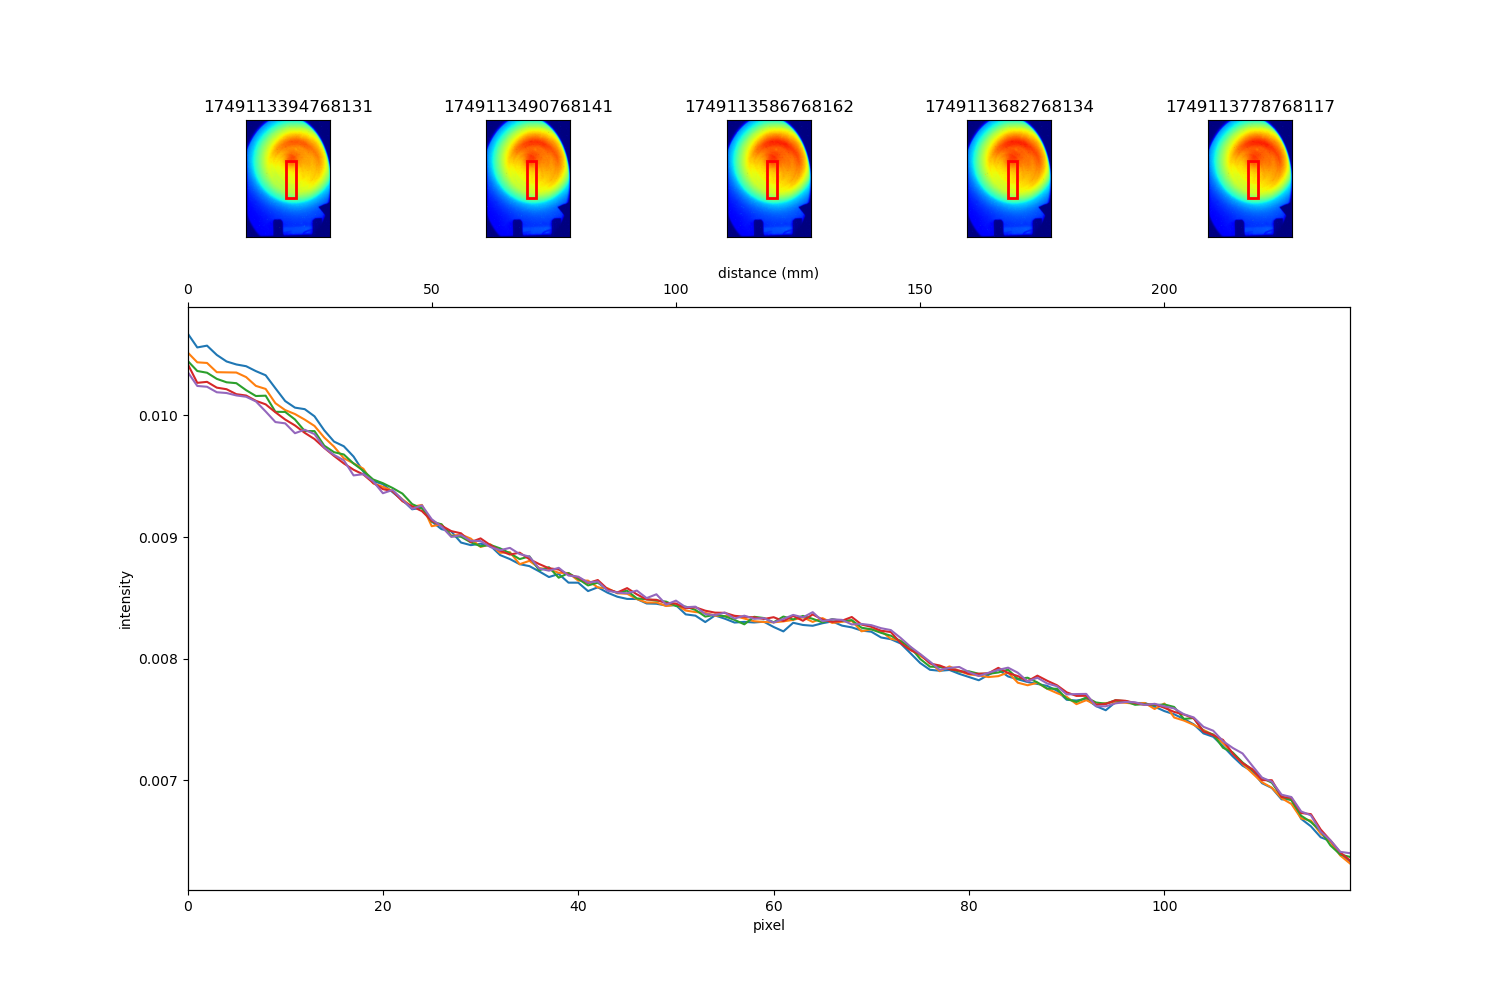

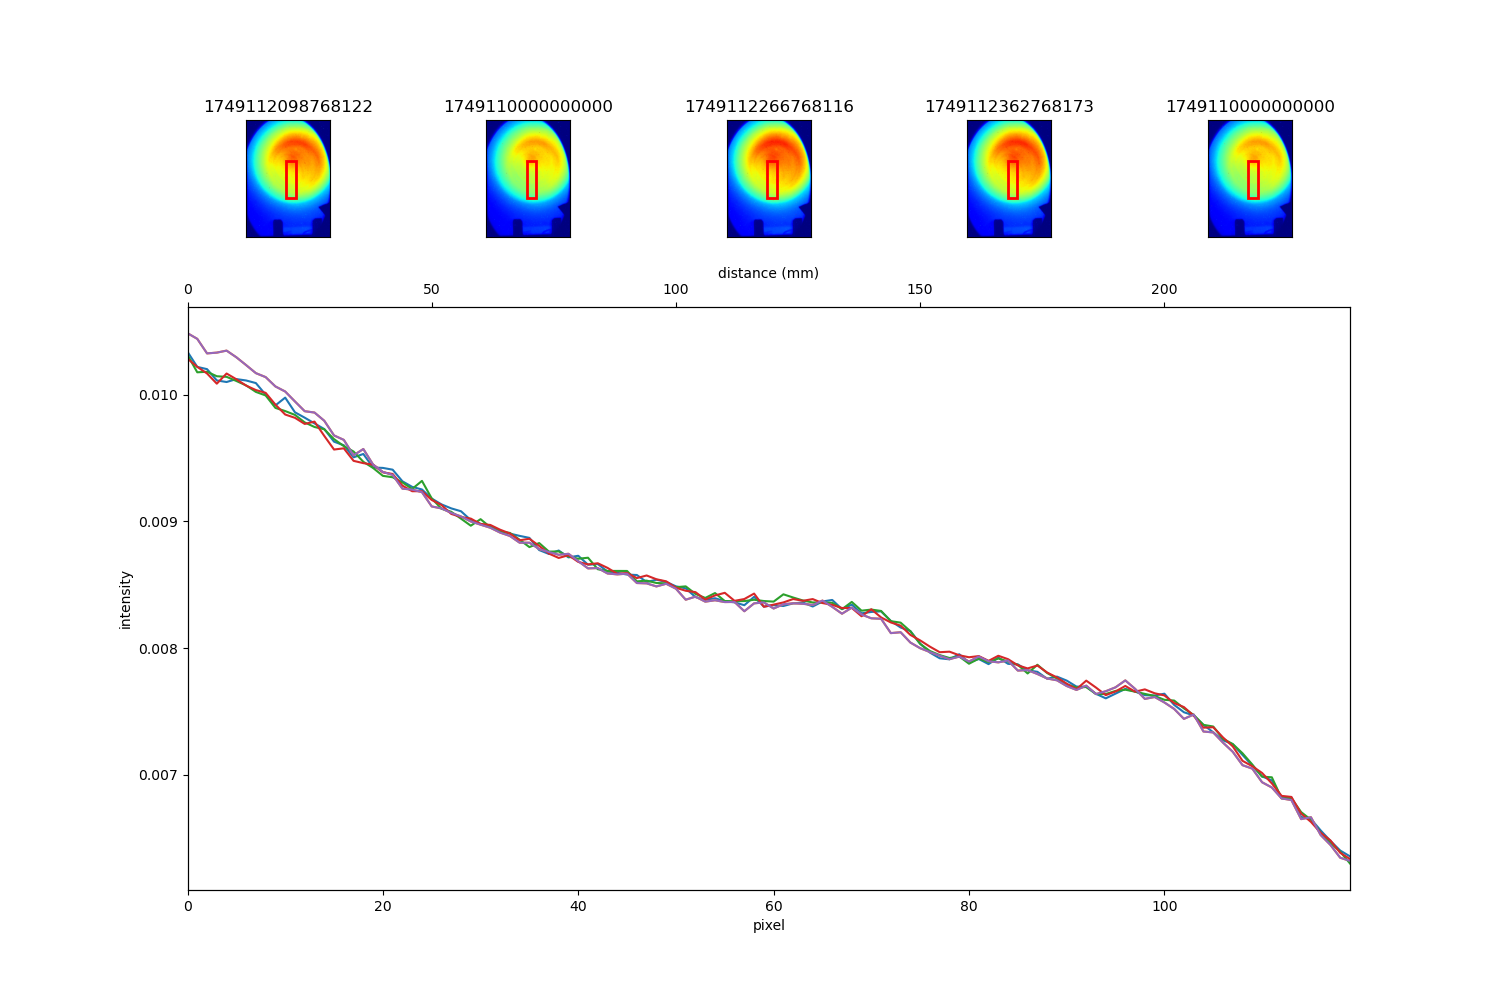

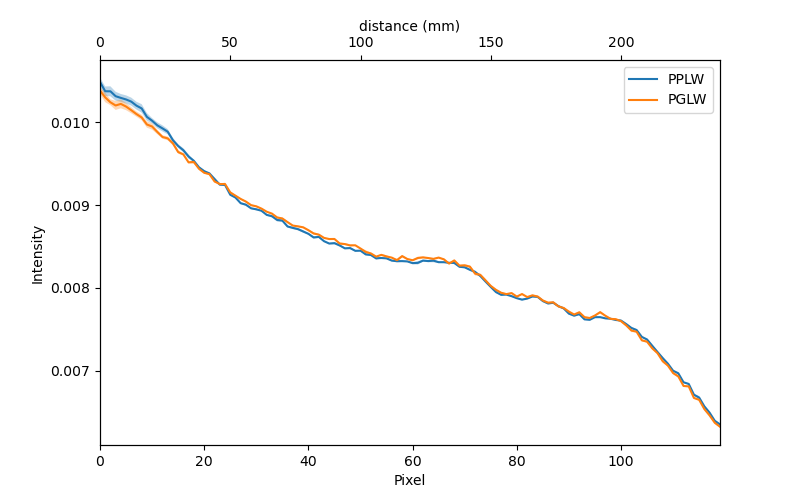

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
plot_group_overview(results["PPLW"])
plot_group_overview(results["PGLW"])
plot_group_comparison(results)

In [18]:
import ipympl
import matplotlib
import ipywidgets
# import jupyterlab

print("ipympl:", ipympl.__version__)
print("matplotlib:", matplotlib.__version__)
print("ipywidgets:", ipywidgets.__version__)

ipympl: 0.10.0
matplotlib: 3.10.8
ipywidgets: 8.1.8


In [11]:
import matplotlib
matplotlib.get_backend()

'widget'

In [12]:
import ipywidgets as widgets
widgets.IntSlider()

IntSlider(value=0)